# HW6 Assigned Problems



In [1]:
# As always, we start with our favorite standard imports. 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

from sklearn import tree

# Optional: display settings
pd.set_option('display.max_columns', None)


## Homework 6 Spring 2026

In this homework, you will work with classification methods, focusing on **decision trees** and **ensemble methods** such as **random forests**. You will explore how model complexity affects performance, use cross-validation to select tuning parameters, and compare models using training and testing error rates.

In addition, you will interpret tree-based models and examine **variable importance** to better understand how predictors influence the response. As in previous assignments, be sure to clearly justify your choices, report relevant metrics, and provide brief interpretations of your results.

---

## Question 1. Classification Tree on the OJ Data Set (30 points)

### (a) (6 points)
Create a training set containing a random sample of **800 observations** and a test set containing the remaining observations.

Report the **percentage of observations** that are included in the training set.

### (b) (6 points)
Fit a **classification tree** to the training data, with **Purchase** as the response and all remaining variables as predictors. To control model complexity, we restrict the tree to have a maximum depth of 3.

Report:
- the fitted model (e.g., a plot or summary of the tree)
- the **training error rate**

### (c) (6 points)
Plot the fitted classification tree and use it to answer the following:

- How many terminal nodes does the tree have?
- Which variables appear near the top of the tree?
- Briefly interpret two of the main splits.

### (d) (6 points)
Use `export_text()` to display a text summary of the fitted classification tree.

Select **one terminal node** and describe:
- the path of splits leading to the node
- the observations in that node
- the predicted class

### (e) (6 points)
Predict on the **test set** and report:
- the confusion matrix
- the **test error rate**

Based on your results, briefly comment on the model’s performance.

---

## Question 2. Cross-Validation and Tree Size (20 points)

### (a) (15 points)
Use cross-validation on the training set to determine an appropriate tree size. Vary the maximum depth of the tree over a range of 1 to 20 and use 5-fold cross-validation to evaluate model performance. Plot **tree size** versus **cross-validated classification error rate**.

### (b) (5 points)
Which tree size achieves the lowest cross-validated classification error rate? Briefly explain your choice based on the plot.

---

## Question 3. Pruned vs. Unpruned Tree (20 points)

### (a) (10 points)
Fit both an **unpruned tree** and a **pruned (or restricted) tree** using the optimal tree size identified in Question 2. If the cross-validation results do not clearly support pruning, fit a smaller reasonable tree instead and briefly justify your choice.

Report:
- the chosen tree size for the pruned/restricted model
- the **training error rate** for each model
- the **testing error rate** for each model

### (b) (3 points)
Which model has the higher **training error rate**, the pruned or unpruned tree?

### (c) (3 points)
Which model performs better on the test set, the pruned or unpruned tree?

### (d) (4 points)
Briefly explain why the pruned and unpruned trees may perform differently on the training and test data.

---

## Question 4. Random Forest (20 points)

Using the **same training and test sets** from Question 1:

### (a) (15 points)
Fit a **random forest** model with **Purchase** as the response variable (use at least 500 trees).

Report:
- the **test error rate**
- the **variable importance** values

### (b) (5 points)
Compare the random forest and classification tree using their **test error rates**, and briefly interpret the most important predictors.

---

## Question 5. Reflection (10 points)

Write a short paragraph addressing the following:

- one advantage of a single decision tree
- one disadvantage of a single decision tree
- why ensemble methods (e.g., random forests) can improve prediction performance

---

### Grading distribution

- **Question 1:** 30 points  
- **Question 2:** 20 points  
- **Question 3:** 20 points  
- **Question 4:** 20 points  
- **Question 5:** 10 points  

**Total:** 100 points

## Data

This homework uses the **OJ** data set. Update the file path below if needed.


In [2]:
url = "https://msu-cmse-courses.github.io/CMSE381-S26/_downloads/73b56f6984db80ab92105d5e86279f38/OJ.csv"
OJ_df = pd.read_csv(url, index_col=0)

# Convert the Store7 column from Yes/No to 1/0 so scikit-learn can use it.
if 'Store7' in OJ_df.columns:
    OJ_df['Store7'] = OJ_df['Store7'].replace({'Yes': 1, 'No': 0})

# Preview the data
print(OJ_df.info())

OJ_df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 1070 entries, 1 to 1070
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Purchase        1070 non-null   object 
 1   WeekofPurchase  1070 non-null   int64  
 2   StoreID         1070 non-null   int64  
 3   PriceCH         1070 non-null   float64
 4   PriceMM         1070 non-null   float64
 5   DiscCH          1070 non-null   float64
 6   DiscMM          1070 non-null   float64
 7   SpecialCH       1070 non-null   int64  
 8   SpecialMM       1070 non-null   int64  
 9   LoyalCH         1070 non-null   float64
 10  SalePriceMM     1070 non-null   float64
 11  SalePriceCH     1070 non-null   float64
 12  PriceDiff       1070 non-null   float64
 13  Store7          1070 non-null   int64  
 14  PctDiscMM       1070 non-null   float64
 15  PctDiscCH       1070 non-null   float64
 16  ListPriceDiff   1070 non-null   float64
 17  STORE           1070 non-null   int64 

,Purchase,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
1,CH,237,1,1.75,1.99,0.00,0.0,0,0,0.500000,1.99,1.75,0.24,0,0.000000,0.000000,0.24,1
2,CH,239,1,1.75,1.99,0.00,0.3,0,1,0.600000,1.69,1.75,-0.06,0,0.150754,0.000000,0.24,1
3,CH,245,1,1.86,2.09,0.17,0.0,0,0,0.680000,2.09,1.69,0.40,0,0.000000,0.091398,0.23,1
4,MM,227,1,1.69,1.69,0.00,0.0,0,0,0.400000,1.69,1.69,0.00,0,0.000000,0.000000,0.00,1
5,CH,228,7,1.69,1.69,0.00,0.0,0,0,0.956535,1.69,1.69,0.00,1,0.000000,0.000000,0.00,0


## Question 1. Classification Tree on the OJ Data Set

### (a) (6 points)
Create a training set containing a random sample of **800 observations** and a test set containing the remaining observations.

Report:
- the percentage of observations in the training set



In [3]:
##ANSWER

X = OJ_df.drop('Purchase', axis=1)
y = OJ_df['Purchase']


# This split matches the provided solution notebook.
# Note: train_test_split returns the train set first, but we keep the same variable
# names used in the original notebook for consistency.
percent = 800/1070

X_test, X_train, y_test, y_train = train_test_split(
    X, y, test_size=percent, random_state=42
)

print(f"Training set size: {percent}")



Training set size: 0.7476635514018691


### (b) (6 points)
Fit a **classification tree** to the training data, with **Purchase** as the response and all remaining variables as predictors. To control model complexity, we restrict the tree to have a maximum depth of 3.

Report:
- the fitted model
- the training error rate


In [4]:
###ANSWER###

clf_tree = DecisionTreeClassifier(max_depth=3)
clf_tree.fit(X_train, y_train)

y_train_pred = clf_tree.predict(X_train)
C_train = confusion_matrix(y_train, y_train_pred)
train_error = 1 - C_train.trace() / C_train.sum()

print(clf_tree)
print(f"Training error rate: {train_error:.3f}")


DecisionTreeClassifier(max_depth=3)
Training error rate: 0.191


### (c) (3 + 3 points): Create a plot of the fitted tree and interpret the results.
1. Create a plot of the fitted tree.



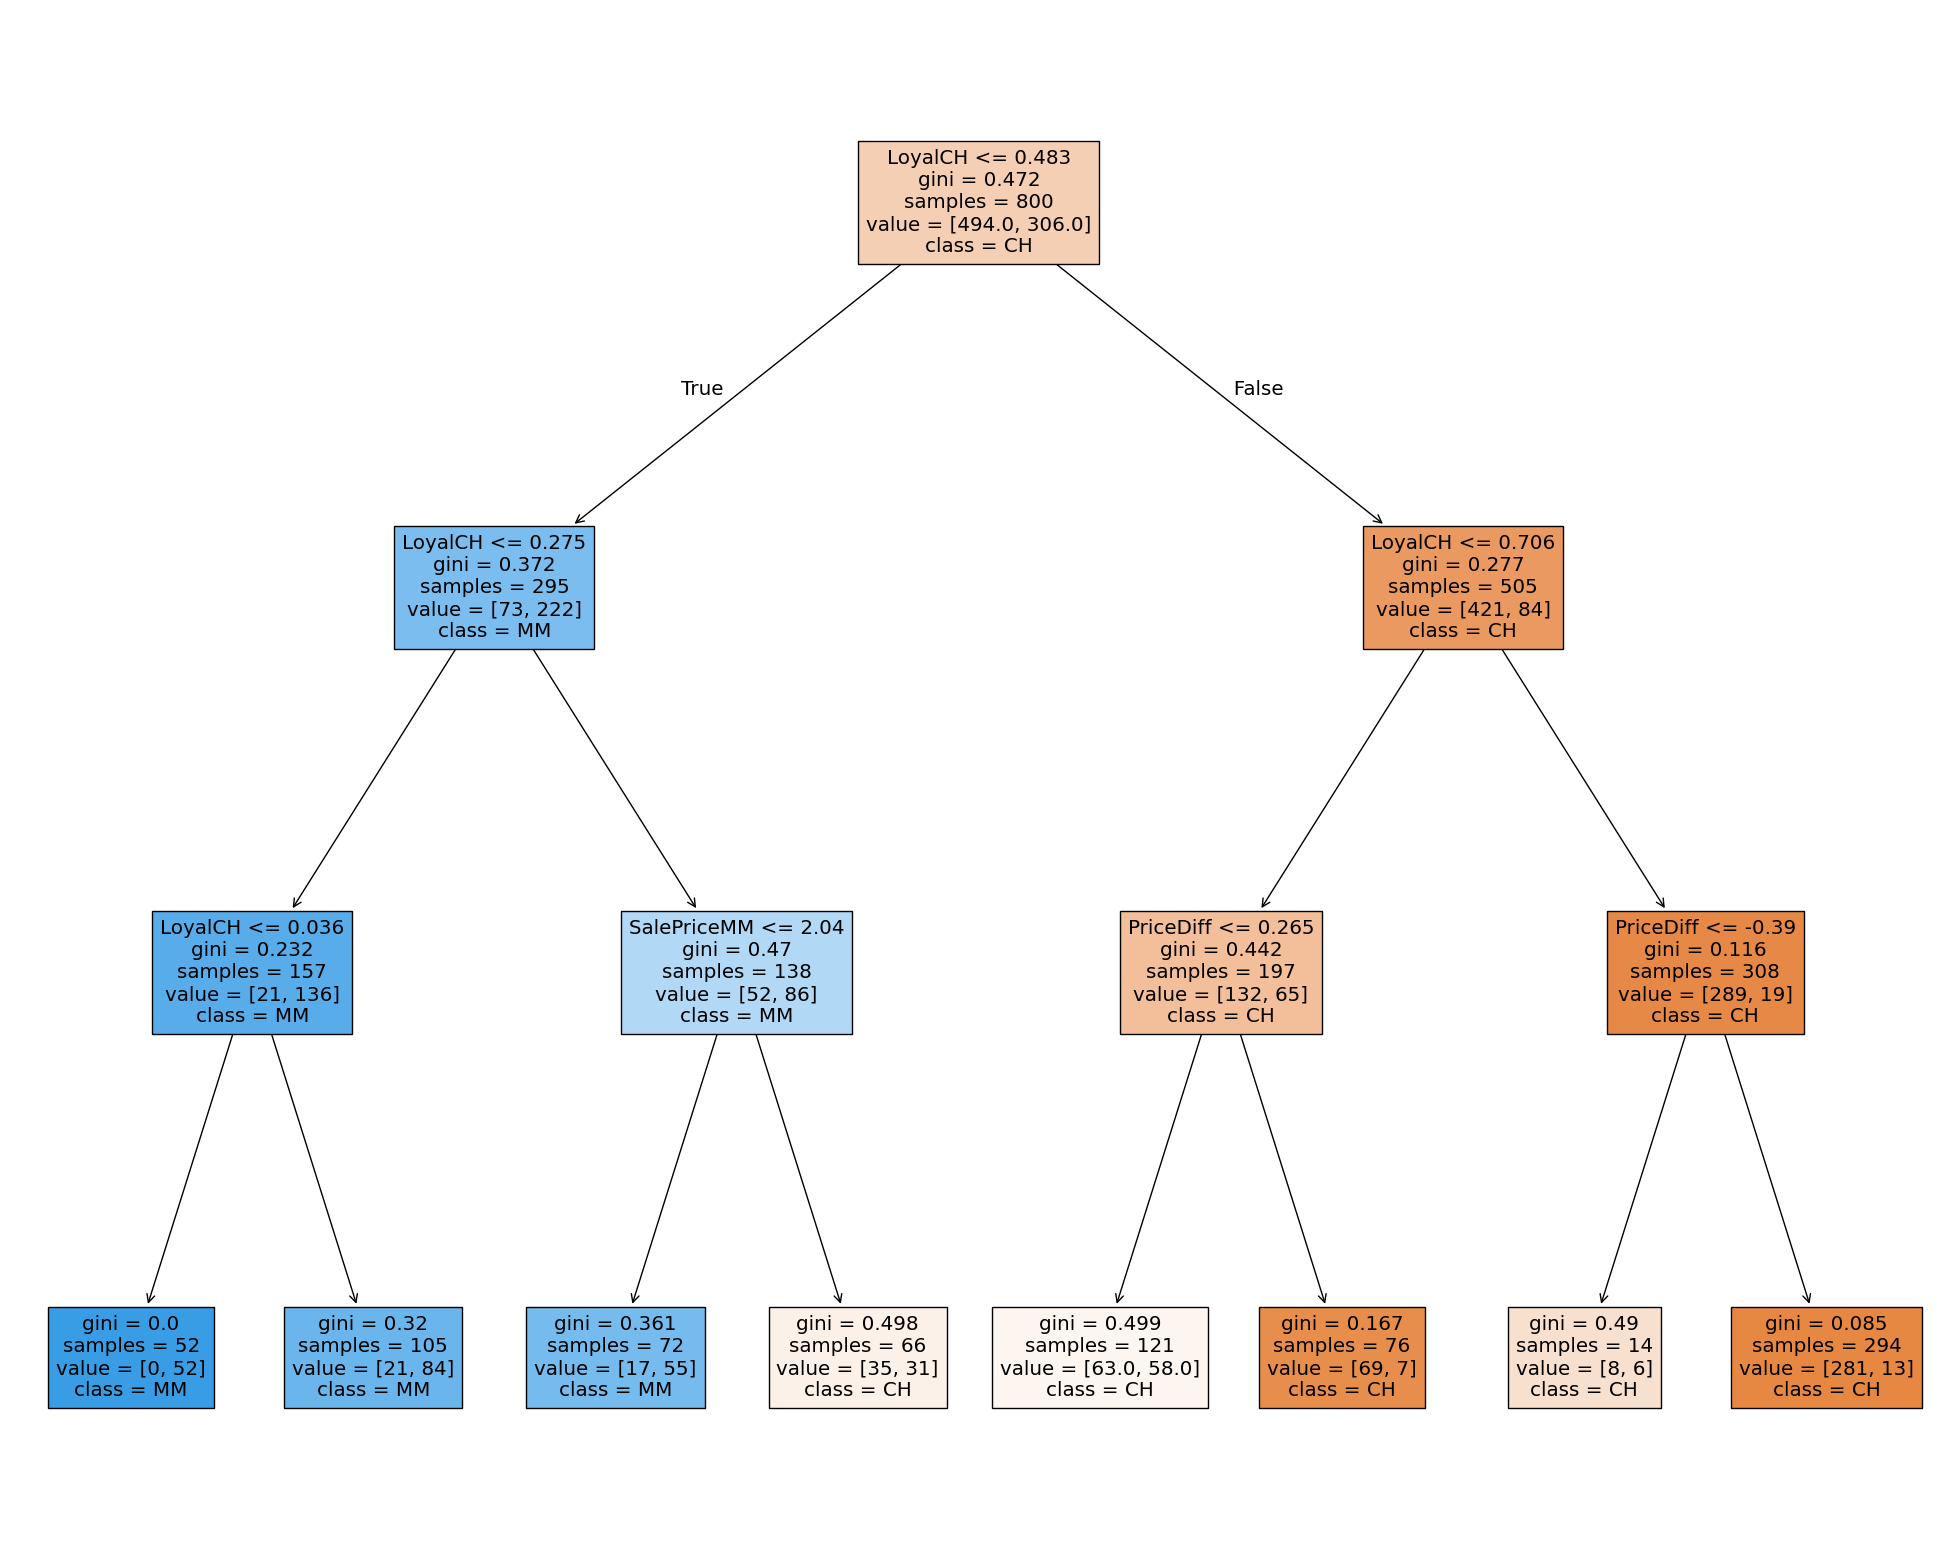

Number of terminal nodes: 8


In [5]:
### CODE ANSWER### 
fig = plt.figure(figsize=(25, 20))
_ = tree.plot_tree(
    clf_tree,
    feature_names=X.columns,
    class_names=clf_tree.classes_,
    filled=True
)
plt.show()

print(f"Number of terminal nodes: {clf_tree.get_n_leaves()}")


### (c)
2. Interpret the results based on the above plot.

Answer the following:
- How many terminal nodes does the tree have?
- Which variables appear near the top of the tree?
- Briefly interpret two of the main splits.

### ANSWER

- Number of terminal nodes: 8  

- Variables near the top of the tree:
  The first split is on LoyalCH. Other important variables appearing near the top include **PriceDiff** and **SalePriceMM**.  

- Interpretation of the main splits:
  - The first split on **LoyalCH** indicates that customer loyalty to Citrus Hill is the most important factor in predicting purchase behavior.  
  - Subsequent splits on **PriceDiff** and **SalePriceMM** suggest that pricing—both the relative price difference and the sale price of Minute Maid—also plays an important role in the classification decision.  


### (d) (3 + 3 points)
1. Use `export_text()` to produce a text summary of the fitted tree.




In [6]:
###ANSWER###
tree_text = export_text(clf_tree, feature_names=list(X.columns))
print(tree_text)


|--- LoyalCH <= 0.48
|   |--- LoyalCH <= 0.28
|   |   |--- LoyalCH <= 0.04
|   |   |   |--- class: MM
|   |   |--- LoyalCH >  0.04
|   |   |   |--- class: MM
|   |--- LoyalCH >  0.28
|   |   |--- SalePriceMM <= 2.04
|   |   |   |--- class: MM
|   |   |--- SalePriceMM >  2.04
|   |   |   |--- class: CH
|--- LoyalCH >  0.48
|   |--- LoyalCH <= 0.71
|   |   |--- PriceDiff <= 0.27
|   |   |   |--- class: CH
|   |   |--- PriceDiff >  0.27
|   |   |   |--- class: CH
|   |--- LoyalCH >  0.71
|   |   |--- PriceDiff <= -0.39
|   |   |   |--- class: CH
|   |   |--- PriceDiff >  -0.39
|   |   |   |--- class: CH



2. Choose **one terminal node** and interpret:
- the path of splits leading to that node
- what type of observations fall into that node
- the predicted class for that node


#ONE ANSWER##

Consider the terminal node defined by the following path:
- LoyalCH ≤ 0.48
- LoyalCH > 0.28
- SalePriceMM > 2.04

This path corresponds to customers with **moderate loyalty** to Citrus Hill (not very low, but also not high). Among these customers, the decision further depends on the **sale price of Minute Maid**.

Observations in this node are customers who are somewhat loyal to CH, but when the sale price of Minute Maid is relatively **high**, they are more likely to switch away from MM.

The predicted class for this node is **CH**, indicating that these customers are more likely to purchase Citrus Hill under these conditions.

### (e) (3 + 3 points)
1. Predict the response on the **test set** and produce a **confusion matrix** comparing the test labels to the predicted test labels.

Report:
- the confusion matrix
- the test error rate



Confusion matrix:
[[147  12]
 [ 31  80]]
Test error rate: 0.159


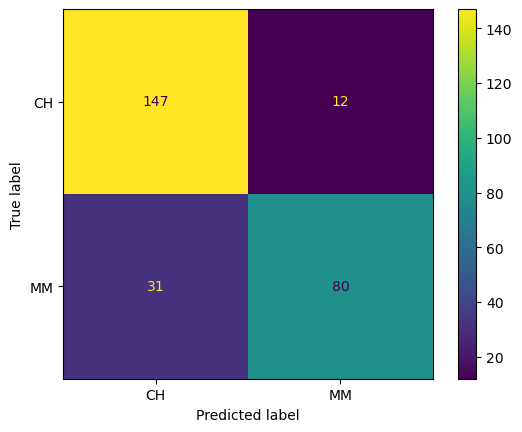

In [7]:
###ANSWER###

y_test_pred = clf_tree.predict(X_test)
C_test = confusion_matrix(y_test, y_test_pred)
test_error = 1 - C_test.trace() / C_test.sum()

print("Confusion matrix:")
print(C_test)
print(f"Test error rate: {test_error:.3f}")

disp = ConfusionMatrixDisplay(C_test, display_labels=clf_tree.classes_)
disp.plot()
plt.show()


### (e) 
2. Based on your results from Question 1(e), briefly comment on the model’s performance.

**Answer for Question 2(e):**

The model achieves a test error rate of approximately **0.159**, indicating good overall predictive performance on the test set. It correctly classifies most observations, particularly for the CH class. However, the model makes more errors when predicting MM, suggesting slightly weaker performance for that class.


## Question 2. Cross-Validation and Tree Size

### (a) (12 points)

Use cross-validation on the training set to determine an appropriate tree size. Vary the maximum depth of the tree over a range of 1 to 20 and use 5-fold cross-validation to evaluate model performance. Plot **tree size** versus **cross-validated classification error rate**.


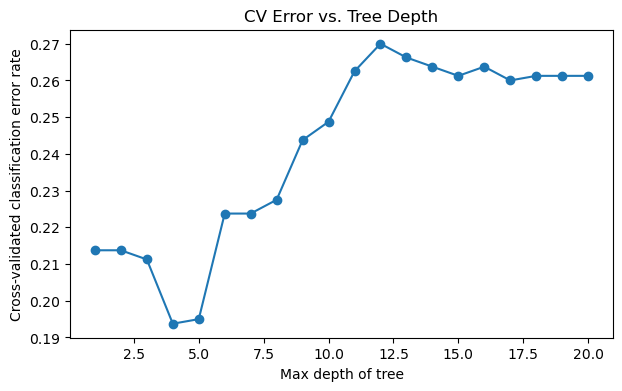

Average CV accuracies: [0.78625, 0.78625, 0.78875, 0.80625, 0.805, 0.7762499999999999, 0.7762499999999999, 0.7725, 0.7562499999999999, 0.75125, 0.7375, 0.73, 0.73375, 0.73625, 0.7387500000000001, 0.7362499999999998, 0.74, 0.7387500000000001, 0.7387500000000001, 0.7387500000000001]
Best depth: 4
Lowest CV error rate: 0.194


In [8]:
###ANSWER###
depths = range(1, 21)
all_scores = []

for depth in depths:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    scores = cross_val_score(clf, X_train, y_train, cv=5)
    all_scores.append(np.mean(scores))

cv_errors = [1 - s for s in all_scores]
best_depth = depths[np.argmax(all_scores)]

plt.figure(figsize=(7, 4))
plt.plot(list(depths), cv_errors, marker='o')
plt.xlabel('Max depth of tree')
plt.ylabel('Cross-validated classification error rate')
plt.title('CV Error vs. Tree Depth')
plt.show()

print("Average CV accuracies:", all_scores)
print(f"Best depth: {best_depth}")
print(f"Lowest CV error rate: {min(cv_errors):.3f}")

#### ✅ Question (a-b): Documenting Your Solution Process (3 points)

Please answer the following clearly and completely:

1. **Prior Knowledge vs. External Resources (1 point)**  
   Indicate which parts of Question (a) you completed using your own prior knowledge, and which parts you completed using external resources (e.g., generative AI, past assignments, Stack Overflow, Google, etc.).

###YOUR ANSWER HERE##

2. **Required Documentation (2 points)**  
   - For any part where you used **generative AI**, you must include the exact prompts you entered and the corresponding AI outputs. **Copy and paste them directly**.  
   - For any part where you used other external resources, list those sources.  
   - For parts completed without external resources, briefly state what prior knowledge you relied on (no detailed explanation required).

Responses that do not include **prompts and AI outputs** (when applicable) will not receive full credit.

In [9]:
### YOUR ANSWER HERE##
#YOUR PROMPTS##

##AI OUTPUTS##

### (b) (5 points)
Which tree size achieves the lowest cross-validated classification error rate? Briefly explain your choice.


###ANSWER###

The optimal tree depth is 4, which yields the lowest cross-validated classification error rate (0.194). This suggests that a relatively simple model provides the best generalization performance, while deeper trees tend to overfit the training data.


## Question 3. Pruned vs. Unpruned Tree


### (a) (10 points)

Fit both an **unpruned tree** and a **pruned (or restricted) tree** using the optimal tree size identified in Question 2. If the cross-validation results do not clearly support pruning, fit a smaller reasonable tree instead and briefly justify your choice.

For each model, report both the **training error rate** and the **testing error rate**, as these will be used for comparison in part (b) and (c).

Be sure to clearly state the chosen tree size (e.g., depth or number of terminal nodes) for the pruned/restricted model.

In [10]:
#### ANSWER ####

# Unpruned tree
tree_clf = DecisionTreeClassifier(random_state=1)
tree_clf.fit(X_train, y_train)

# Restricted tree based on CV result from Question 2
# Here, the best depth was 1
tree_clf_pruned = DecisionTreeClassifier(max_depth=1, random_state=1)
tree_clf_pruned.fit(X_train, y_train)

# Training errors
unpruned_train_error = 1 - tree_clf.score(X_train, y_train)
pruned_train_error = 1 - tree_clf_pruned.score(X_train, y_train)

# Testing errors
unpruned_test_error = 1 - tree_clf.score(X_test, y_test)
pruned_test_error = 1 - tree_clf_pruned.score(X_test, y_test)

# Print results
print("Unpruned tree:")
print(f"  Training error: {unpruned_train_error:.3f}")
print(f"  Testing error:  {unpruned_test_error:.3f}")

print("Pruned/restricted tree:")
print(f"  Training error: {pruned_train_error:.3f}")
print(f"  Testing error:  {pruned_test_error:.3f}")

Unpruned tree:
  Training error: 0.011
  Testing error:  0.204
Pruned/restricted tree:
  Training error: 0.196
  Testing error:  0.174


### (b) (3 points)
Compare the **training error rates** of the pruned and unpruned trees. Which is higher?

###ANSWER###
- **Training error comparison:**  
  - Pruned tree training error: **0.196**  
  - Unpruned tree training error: **0.011**  
  The **unpruned tree** has a much lower training error, as expected, since it is more flexible and fits the training data more closely.

### (c) (3 points)
Compare the **test error rates** of the pruned and unpruned trees. Which model performs better?

###ANSWER###
- **Test error comparison:**  
  - Pruned tree test error: **0.174**  
  - Unpruned tree test error: **0.204**  
  The **pruned tree** achieves a lower test error, indicating better performance on unseen data.

### (d) (4 points)
Briefly explain why the pruned and unpruned trees may perform differently on training and test data.


###ANSWER###

The unpruned tree overfits the training data by capturing noise, resulting in very low training error but worse test performance. In contrast, the pruned tree reduces model complexity, leading to higher training error but improved generalization and lower test error.

## Question 4. Random Forest

Using the **same training and test sets** from Question 1:

### (a) (12 points)
Fit a **random forest** model with **Purchase** as the response variable. Use at least 500 trees.  
Report the **test error rate** and display the **variable importance** values.



In [11]:
#ANSWER###

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42
)
rf.fit(X_train, y_train)

y_rf = rf.predict(X_test)
C_rf = confusion_matrix(y_test, y_rf)
rf_test_error = 1 - C_rf.trace() / C_rf.sum()

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print(f"Random forest test error rate: {rf_test_error:.3f}")
print("\nTop variable importances:")
print(importances.head(10))


Random forest test error rate: 0.193

Top variable importances:
LoyalCH           0.541575
WeekofPurchase    0.116494
PriceDiff         0.049126
StoreID           0.048475
STORE             0.032991
ListPriceDiff     0.030971
SalePriceMM       0.029934
SalePriceCH       0.020965
PctDiscMM         0.017936
PriceCH           0.017312
dtype: float64


#### ✅ Question (a-b): Documenting Your Solution Process (3 points)

Please answer the following clearly and completely:

1. **Prior Knowledge vs. External Resources (1 point)**  
   Indicate which parts of Question (A) you completed using your own prior knowledge, and which parts you completed using external resources (e.g., generative AI, past assignments, Stack Overflow, Google, etc.).

###YOUR ANSWER HERE##

2. **Required Documentation (2 points)**  
   - For any part where you used **generative AI**, you must include the exact prompts you entered and the corresponding AI outputs. **Copy and paste them directly**.  
   - For any part where you used other external resources, list those sources.  
   - For parts completed without external resources, briefly state what prior knowledge you relied on (no detailed explanation required).

Responses that do not include **prompts and AI outputs** (when applicable) will not receive full credit.

In [13]:
### YOUR ANSWER HERE##
#YOUR PROMPTS##

##AI OUTPUTS##

### (b) (5 points)
Compare the random forest with the classification tree from Question 3 using their test error rates.  
Identify the most important predictors and briefly interpret the results.

###ANSWER### 

The random forest has a slightly higher test error than the pruned classification tree, indicating that the pruned tree performs better on the test set.

The most important predictor is **LoyalCH**, followed by **WeekofPurchase** and **PriceDiff**, suggesting that customer loyalty has the strongest influence on purchase decisions.

## Question 5. Reflection (10 points)

Write a short paragraph addressing the following:

1. What is one advantage of a single decision tree?
2. What is one disadvantage of a single decision tree?
3. Why can ensemble methods such as random forests often improve prediction performance?


### Answer to Question 5

A single decision tree is easy to interpret because the prediction rule can be explained through a sequence of simple if-then splits. This makes trees attractive when we want a model that is transparent and easy to communicate. However, a single tree can be unstable and may have relatively high variance, since small changes in the data can lead to a different tree. Ensemble methods such as random forests improve prediction performance by combining many trees built from resampled data and random subsets of predictors, which reduces variance and usually leads to more accurate and more stable predictions.
